## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [3]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# notebook configuration
pd.set_option('display.max_columns', None)

In [18]:
# Load the dataset

df = pd.read_csv('Churn_Modelling_train_test.csv')

# drop unnecessary columns

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# define features and target

X = df.drop('Exited', axis=1)
y = df['Exited']

# split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7200, 10)
Test shape: (1801, 10)


In [5]:
# dataset analysis
# dataset analysis

print("Dataset shape:", df.shape)

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

Dataset shape: (9001, 14)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB
None

Missing values:
RowNumber          0
CustomerI

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,9001.000000,9.001000e+03,9001.000000,9000.000000,9001.000000,9001.000000,9001.000000,9000.000000,9001.000000,9001.000000,9001.000000
mean,5003.366515,1.569072e+07,650.681369,38.901781,5.007888,76222.210827,1.531497,0.705667,0.514721,100180.823967,0.204422
std,2884.787499,7.179353e+04,96.539591,10.450760,2.894025,62432.198151,0.579398,0.455768,0.499811,57561.189534,0.403301
min,2.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2509.000000,1.562811e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,50972.600000,0.000000
50%,4989.000000,1.569096e+07,652.000000,37.000000,5.000000,96997.090000,1.000000,1.000000,1.000000,100556.980000,0.000000
75%,7505.000000,1.575265e+07,718.000000,44.000000,7.000000,127450.140000,2.000000,1.000000,1.000000,149458.730000,0.000000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [7]:
# review categorical variables
# review categorical variables

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

# visualize categori


Column: Surname
Surname
Smith          29
Yeh            25
Martin         25
Walker         24
Genovese       23
               ..
Beit            1
Onwuamaegbu     1
Edith           1
Holder          1
Macrossan       1
Name: count, Length: 2772, dtype: int64

Column: Geography
Geography
France     4505
Spain      2250
Germany    2245
Name: count, dtype: int64

Column: Gender
Gender
Male      4906
Female    4095
Name: count, dtype: int64



Column: HasCrCard
HasCrCard
1.0    6351
0.0    2649
Name: count, dtype: int64


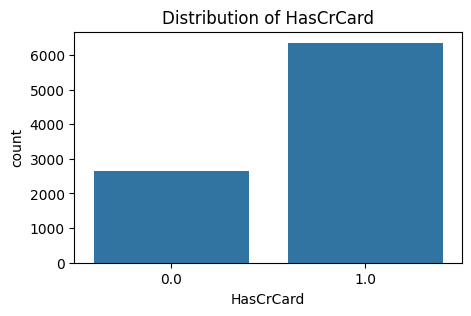


Column: IsActiveMember
IsActiveMember
1.0    4633
0.0    4368
Name: count, dtype: int64


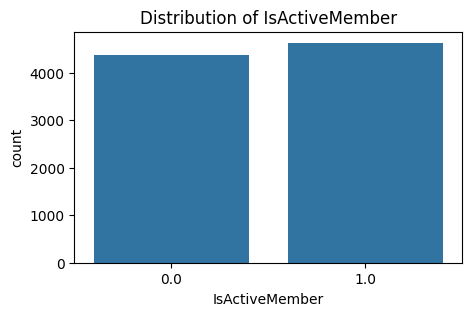


Column: Exited
Exited
0    7161
1    1840
Name: count, dtype: int64


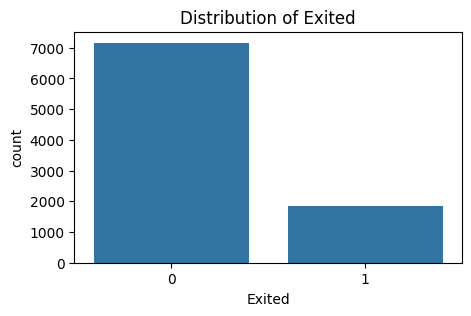

In [8]:
# review binary variables
# review binary variables

binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']

for col in binary_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,9001.000000,9.001000e+03,9001.000000,9000.000000,9001.000000,9001.000000,9001.000000,9000.000000,9001.000000,9001.000000
mean,5003.366515,1.569072e+07,650.681369,38.901781,5.007888,76222.210827,1.531497,0.705667,0.514721,100180.823967
std,2884.787499,7.179353e+04,96.539591,10.450760,2.894025,62432.198151,0.579398,0.455768,0.499811,57561.189534
min,2.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,2509.000000,1.562811e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.000000,0.000000,50972.600000
50%,4989.000000,1.569096e+07,652.000000,37.000000,5.000000,96997.090000,1.000000,1.000000,1.000000,100556.980000
75%,7505.000000,1.575265e+07,718.000000,44.000000,7.000000,127450.140000,2.000000,1.000000,1.000000,149458.730000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


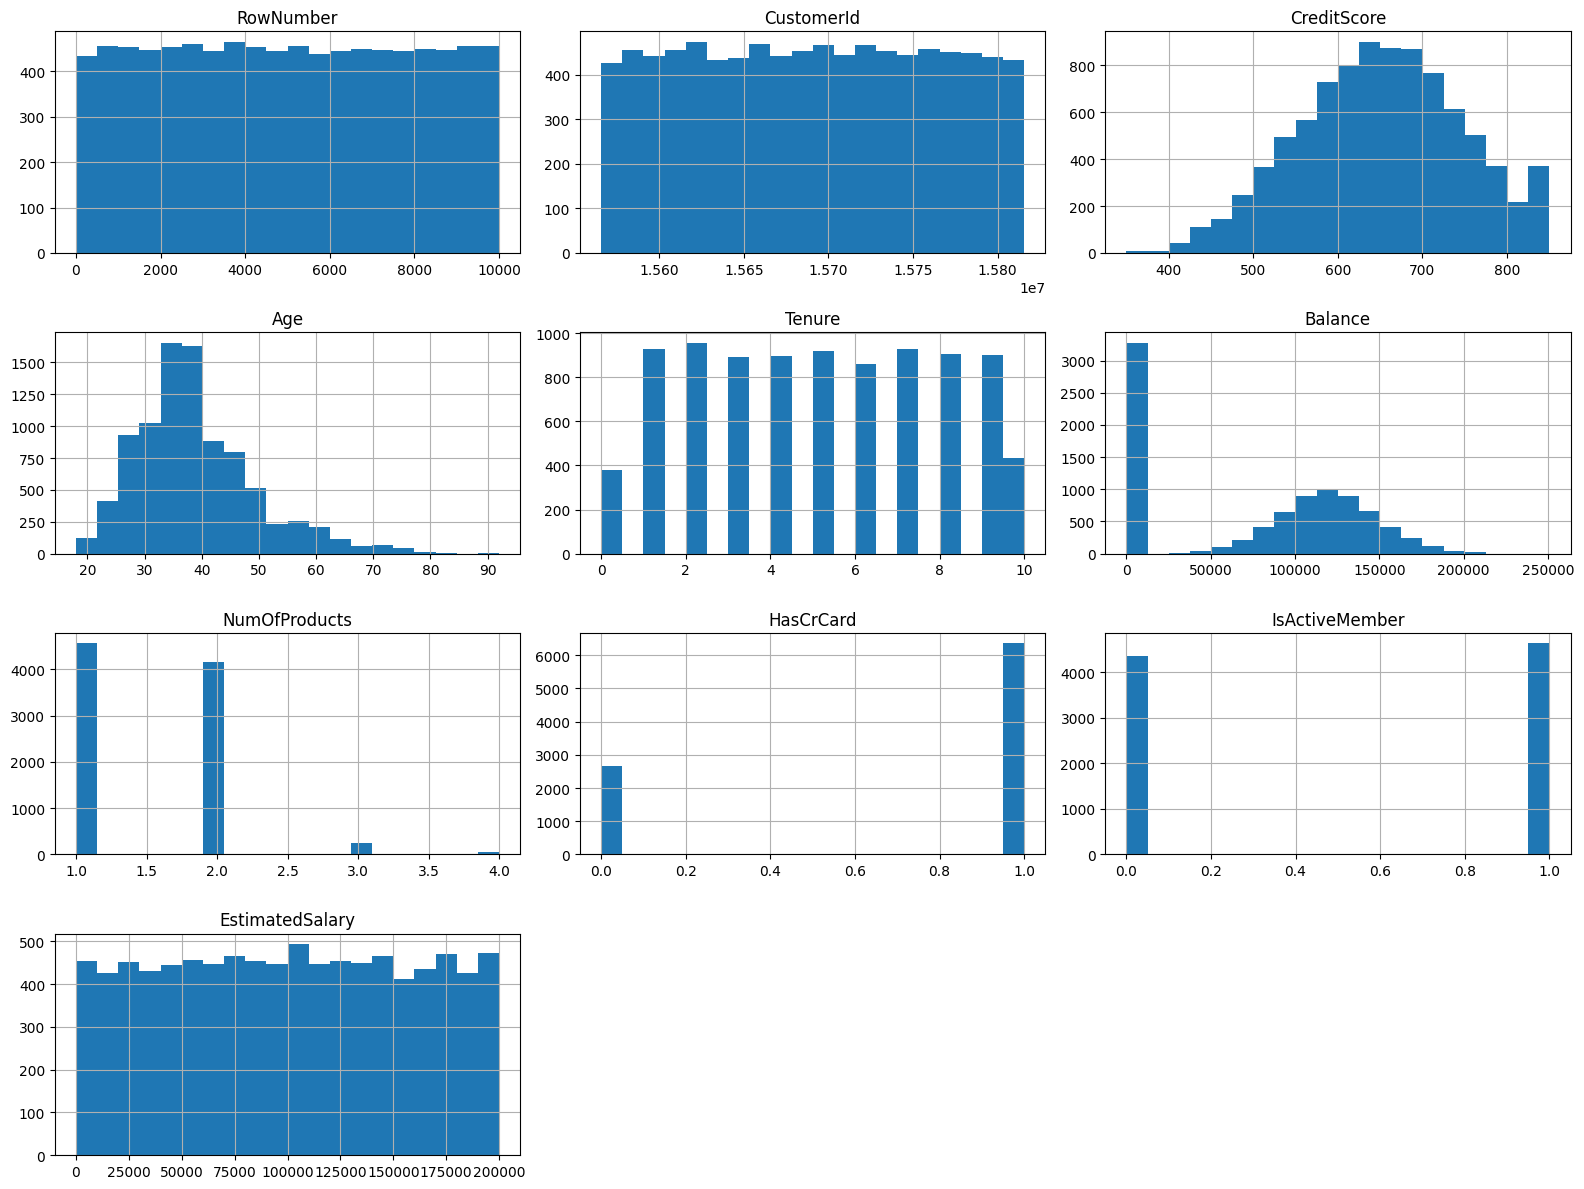

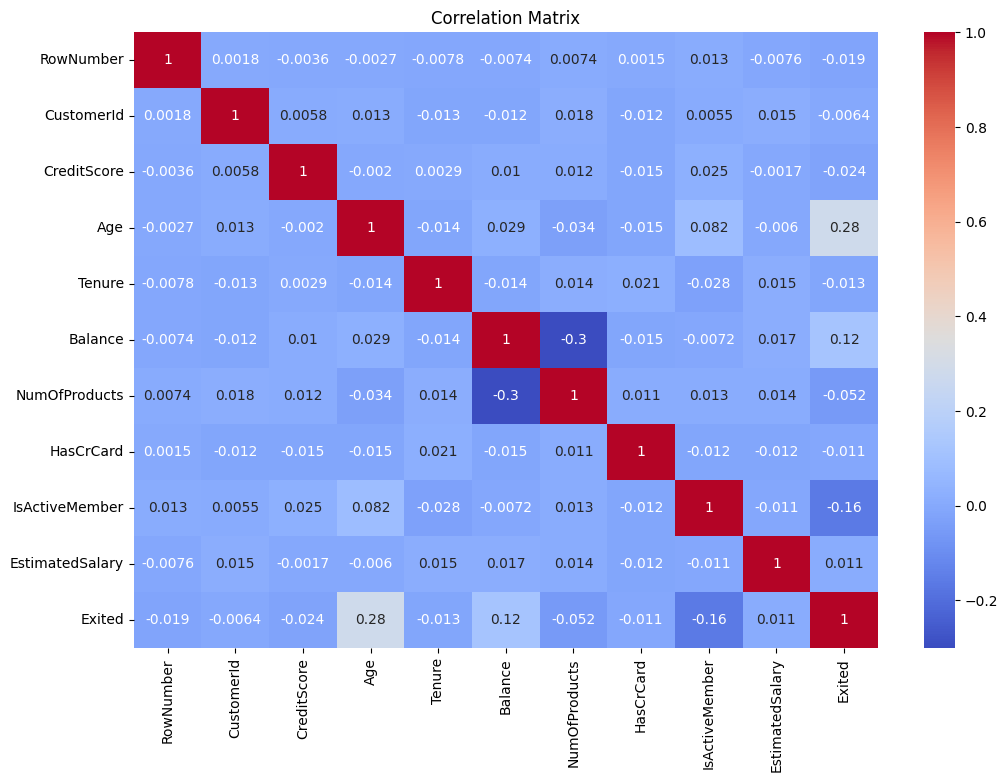

In [9]:
# review numerical variables
# review numerical variables

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# remove target from visualization
numerical_cols = [col for col in numerical_cols if col != 'Exited']

# descriptive statistics

display(df[numerical_cols].describe())

# histograms

df[numerical_cols].hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

# correlation matrix

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:
* The dataset contains customer information related to bank churn.

* The target variable is `Exited`, where:

    * 1 = customer left the bank

    * 0 = customer stayedd

* Most variables are numericall

* `Geography` and `Gender` are categorical variables

* Some features like `Age`, `Balance`, and `IsActiveMember` seem important for predicting churn

* Preprocessing is necessary before training the model

* The dataset is slightly imbalanced

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [ ]:
# import packages
import pandas as pd

In [22]:
# Load the dataset

df = pd.read_csv('Churn_Modelling_train_test.csv')
# drop unnecessary columns

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# define features and target

X = df.drop('Exited', axis=1)
y = df['Exited']

# split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7200, 10)
Test shape: (1801, 10)


In [13]:
# Preprocess the features - create a function or a class for it 
# Preprocess the features - create a function or a class for it

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


def transform():

    categorical_features = ['Geography', 'Gender']

    numerical_features = [
        'CreditScore',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'HasCrCard',
        'IsActiveMember',
        'EstimatedSalary'
    ]

    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    return preprocessor


preprocessor = transform()
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'HasCrCard',
                                  'IsActiveMember', 'EstimatedSalary']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Geography', 'Gender'])])

In [13]:
# balance the dataset (if you think it is necessary)

print("Target distribution before balancing:")
print(y_train.value_counts(normalize=True))

# For this exercise we will keep the original distribution.
# Decision Trees can still perform well with slight imbalance.

Target distribution before balancing:
Exited
0    0.795556
1    0.204444
Name: proportion, dtype: float64


In [23]:
# Train a decision tree model using the train sample

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:8080")

with mlflow.start_run():

    mlflow.sklearn.log_model(model, "decision_tree_model")

    print("Model logged successfully!")

Model trained successfully!


2026/05/26 20:54:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Model logged successfully!
🏃 View run sneaky-bug-988 at: http://127.0.0.1:8080/#/experiments/0/runs/f4b64c2ae3c84b5a8636eafe2236323d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/0


In [15]:
# Check the accuracy of the model on the test sample

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

Accuracy: 0.8579

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1433
           1       0.79      0.41      0.54       368

    accuracy                           0.86      1801
   macro avg       0.83      0.69      0.73      1801
weighted avg       0.85      0.86      0.84      1801



### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [10]:
# import packages for mlfow
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:8080")

print(mlflow.get_tracking_uri())

http://127.0.0.1:8080


Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [6]:
# Set our tracking server uri for logging on port 8080
mlflow.set_tracking_uri("file:./mlruns")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: file:./mlruns


Visit the MLFlow UI on `http://127.0.0.1:8080`

In [20]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
experiment_name = "Practice Experiment - Alejandro Ospina"

mlflow.set_experiment(experiment_name)

print(f"Experiment '{experiment_name}' created or selected.")

2026/05/14 20:30:54 INFO mlflow.tracking.fluent: Experiment with name 'Practice Experiment - Alejandro Ospina' does not exist. Creating a new experiment.


Experiment 'Practice Experiment - Alejandro Ospina' created or selected.


In [11]:
# Start an MLflow run
with mlflow.start_run():

    mlflow.log_param("test", "session3")

    print("Run created successfully!")

Run created successfully!
🏃 View run bold-boar-509 at: http://127.0.0.1:8080/#/experiments/0/runs/0187fed38f3544b1babc412749cf3cfc
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/0


In [24]:
# Start an MLflow run
accuracy = 0.85
with mlflow.start_run():

    # log parameters

    mlflow.log_param("model_type", "DecisionTreeClassifier")

    mlflow.log_param("max_depth", 5)

    mlflow.log_param("random_state", 42)

    # log metrics

    mlflow.log_metric("accuracy", accuracy)

    # log model

    mlflow.sklearn.log_model(model, "decision_tree_model")

    # add tags

    mlflow.set_tag("project", "Churn Modelling Pipeline")

    mlflow.set_tag("author", "Alejandro Ospina")

    print("MLflow run completed successfully!")

2026/05/26 20:55:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run completed successfully!
🏃 View run orderly-moose-793 at: http://127.0.0.1:8080/#/experiments/0/runs/50cedc1a0d754078b75019a45fa58d30
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/0


### Keep practicing

In [3]:
# Create a new experiment using other models or different parameters
...